# NZ Road Crash Severity Predictor
## 297.201 Data Science Project 3

**Dataset:** NZ Crash Analysis System (CAS) — Waka Kotahi Open Data  
**Goal:** Predict whether a crash will be Minor, Serious, or Fatal  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  

---
### Why this matters
Thousands of crashes happen on NZ roads every year. If we can predict which conditions lead to fatal crashes, Waka Kotahi can use that to decide where to spend money on road safety — new signs, lower speed limits, better lighting. This project builds a machine learning model to do exactly that, using real NZ crash data.


## 1. Install and Import Libraries

In [1]:
# Install required packages
import subprocess, sys
for p in ['pandas','numpy','matplotlib','seaborn','scikit-learn','plotly','joblib']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])

import warnings
warnings.filterwarnings('ignore')

# Data tools
import pandas as pd
import numpy as np
import json

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
import joblib

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('All imports successful ✓')

All imports successful ✓


## 2. Load the Data

In [2]:
# Load the CSV file — make sure it's in the same folder as this notebook
DATA_PATH = 'Crash_Analysis_System_(CAS)_data.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded 913,464 rows and 72 columns


,X,Y,OBJECTID,advisorySpeed,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,...,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,1747565.0,5427642.0,1,NaN,575300.0,0.0,NaN,0.0,2.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
1,1544693.0,5170620.0,2,NaN,587020.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
2,1615685.0,5423963.0,3,NaN,584201.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Urban,0.0,0.0,0.0,Fine,Null


In [3]:
# Print all column names so we know what we have
print(df_raw.columns.tolist())

['X', 'Y', 'OBJECTID', 'advisorySpeed', 'areaUnitID', 'bicycle', 'bridge', 'bus', 'carStationWagon', 'cliffBank', 'crashDirectionDescription', 'crashFinancialYear', 'crashLocation1', 'crashLocation2', 'crashRoadSideRoad', 'crashSeverity', 'crashSHDescription', 'crashYear', 'debris', 'directionRoleDescription', 'ditch', 'fatalCount', 'fence', 'flatHill', 'guardRail', 'holiday', 'houseOrBuilding', 'intersection', 'kerb', 'light', 'meshblockId', 'minorInjuryCount', 'moped', 'motorcycle', 'NumberOfLanes', 'objectThrownOrDropped', 'otherObject', 'otherVehicleType', 'overBank', 'parkedVehicle', 'pedestrian', 'phoneBoxEtc', 'postOrPole', 'region', 'roadCharacter', 'roadLane', 'roadSurface', 'roadworks', 'schoolBus', 'seriousInjuryCount', 'slipOrFlood', 'speedLimit', 'strayAnimal', 'streetLight', 'suv', 'taxi', 'temporarySpeedLimit', 'tlaId', 'tlaName', 'trafficControl', 'trafficIsland', 'trafficSign', 'train', 'tree', 'truck', 'unknownVehicleType', 'urban', 'vanOrUtility', 'vehicle', 'waterRi

## 3. Clean the Data

In [4]:
df = df_raw.copy()

# Finding the severity column automatically (it might have different capitalisation)
if 'crashSeverity' in df.columns:
    target_col = 'crashSeverity'
elif 'CRASH_SEVERITY' in df.columns:
    target_col = 'CRASH_SEVERITY'
else:
    candidates = [c for c in df.columns if 'everit' in c.lower()]
    target_col = candidates[0]

print('Target column:', target_col)
print(df[target_col].value_counts())

Target column: crashSeverity
crashSeverity
Non-Injury Crash    638663
Minor Crash         213944
Serious Crash        52526
Fatal Crash           8331
Name: count, dtype: int64


In [5]:
# Removes non-injury crashes — we only care about crashes that hurt people
injury_mask = ~df[target_col].str.lower().str.contains('non-injury|non injury|property', na=False)
df = df[injury_mask].copy()
print(f'Rows after filter: {df.shape[0]:,}')
print(df[target_col].value_counts())

Rows after filter: 274,801
crashSeverity
Minor Crash      213944
Serious Crash     52526
Fatal Crash        8331
Name: count, dtype: int64


In [6]:
WANTED = [
    'speedLimit', 'weatherA', 'light', 'roadSurface', 'roadCharacter',
    'crashSHDescription', 'junctionType', 'trafficControl', 'numberOfLanes',
    'flatHill', 'urban', 'holiday', 'crashYear', 'region',
    'pedestrian', 'bicycle', 'motorcycle', 'truck', 'bus',
    'vehicle', 'schoolBus', 'multipleVehicle'
]
features = [c for c in WANTED if c in df.columns]
print(f'Using {len(features)} features:', features)

df_model = df[features + [target_col]].copy()

Using 19 features: ['speedLimit', 'weatherA', 'light', 'roadSurface', 'roadCharacter', 'crashSHDescription', 'trafficControl', 'flatHill', 'urban', 'holiday', 'crashYear', 'region', 'pedestrian', 'bicycle', 'motorcycle', 'truck', 'bus', 'vehicle', 'schoolBus']


In [7]:
missing = df_model.isnull().sum()
missing_pct = (missing / len(df_model) * 100).round(1)
display(pd.DataFrame({'missing': missing, 'pct_%': missing_pct})[missing > 0].sort_values('pct_%', ascending=False))

,missing,pct_%
holiday,258942,94.2
pedestrian,248692,90.5
vehicle,162595,59.2
region,1018,0.4
speedLimit,946,0.3
crashSHDescription,3,0.0
bicycle,5,0.0
motorcycle,5,0.0
truck,5,0.0
bus,5,0.0


In [8]:
num_cols = df_model.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in df_model.select_dtypes(include='object').columns if c != target_col]

for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())
for c in cat_cols:
    df_model[c] = df_model[c].fillna('Unknown')

print('Missing values left:', df_model.isnull().sum().sum())

Missing values left: 0


In [9]:
# This creates a new column for each category e.g. weatherA_Fine, weatherA_Rain etc.
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Convert the target (severity) to numbers: 0, 1, 2
le = LabelEncoder()
y = le.fit_transform(df_encoded[target_col])
X = df_encoded.drop(columns=[target_col])

label_names = le.classes_.tolist()
print('Severity classes:', label_names)
print(f'Input shape: {X.shape}')

Severity classes: ['Fatal Crash', 'Minor Crash', 'Serious Crash']
Input shape: (274801, 62)


In [10]:
cat_options = {c: sorted(df_model[c].unique().tolist()) for c in cat_cols}
num_ranges  = {c: {'min': float(df_model[c].min()),
                   'max': float(df_model[c].max()),
                   'mean': float(df_model[c].mean())} for c in num_cols}

feature_meta = {
    'feature_names': X.columns.tolist(),
    'label_names': label_names,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'cat_options': cat_options,
    'num_ranges': num_ranges
}
with open('feature_meta.json', 'w') as f:
    json.dump(feature_meta, f)
with open('feature_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)
print('Saved feature info ✓')

Saved feature info ✓


## 4. Explore the Data (EDA)

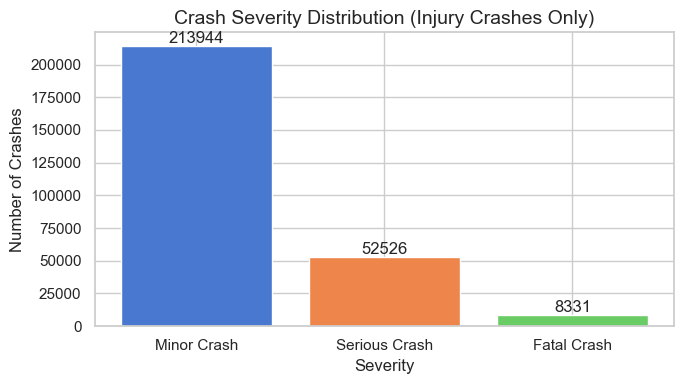

In [11]:
# How many crashes of each severity.
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_model[target_col].value_counts()
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
ax.bar_label(bars, fmt='%d')
ax.set_title('Crash Severity Distribution (Injury Crashes Only)', fontsize=14)
ax.set_xlabel('Severity')
ax.set_ylabel('Number of Crashes')
plt.tight_layout()
plt.savefig('fig_severity_dist.png', dpi=150)
plt.show()

In [12]:
# How have crashes changed over the years.
if 'crashYear' in df_model.columns:
    year_sev = df_model.groupby(['crashYear', target_col]).size().reset_index(name='count')
    fig = px.line(year_sev, x='crashYear', y='count', color=target_col,
                  title='Injury Crashes by Year and Severity',
                  labels={'crashYear': 'Year', 'count': 'Crashes'})
    fig.show()
    fig.write_html('fig_crashes_by_year.html')

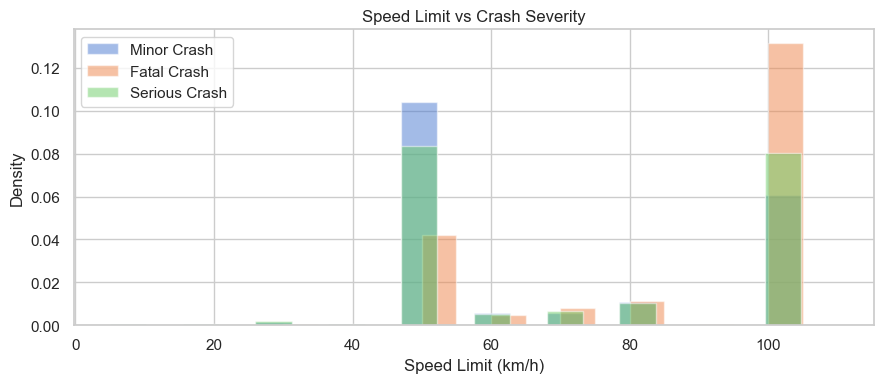

In [13]:
# Does speed limit affect how bad a crash is.
if 'speedLimit' in df_model.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    for sev in df_model[target_col].unique():
        df_model[df_model[target_col] == sev]['speedLimit'].hist(
            bins=20, alpha=0.5, label=sev, density=True, ax=ax)
    ax.set_title('Speed Limit vs Crash Severity')
    ax.set_xlabel('Speed Limit (km/h)')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_speed_severity.png', dpi=150)
    plt.show()

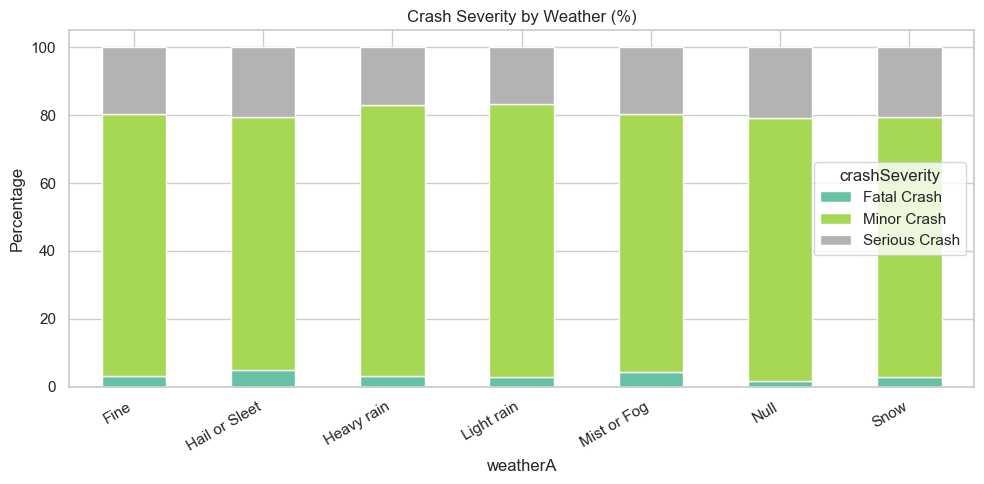

In [14]:
# Does weather affect crash severity.
if 'weatherA' in df_model.columns:
    ws = df_model.groupby(['weatherA', target_col]).size().unstack(fill_value=0)
    ws_pct = ws.div(ws.sum(axis=1), axis=0) * 100
    ws_pct.plot(kind='bar', stacked=True, figsize=(10, 5),
                colormap='Set2', title='Crash Severity by Weather (%)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fig_weather_severity.png', dpi=150)
    plt.show()

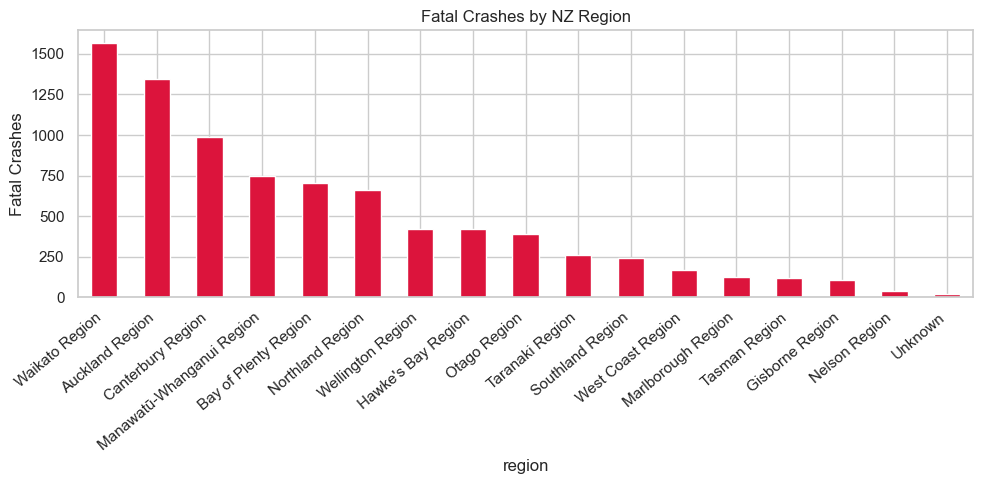

In [15]:
# Which regions have the most fatal crashes.
if 'region' in df_model.columns:
    fatal_mask = df_model[target_col].str.lower().str.contains('fatal')
    region_fatal = df_model[fatal_mask].groupby('region').size().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    region_fatal.plot(kind='bar', ax=ax, color='crimson')
    ax.set_title('Fatal Crashes by NZ Region')
    ax.set_ylabel('Fatal Crashes')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.savefig('fig_region_fatal.png', dpi=150)
    plt.show()

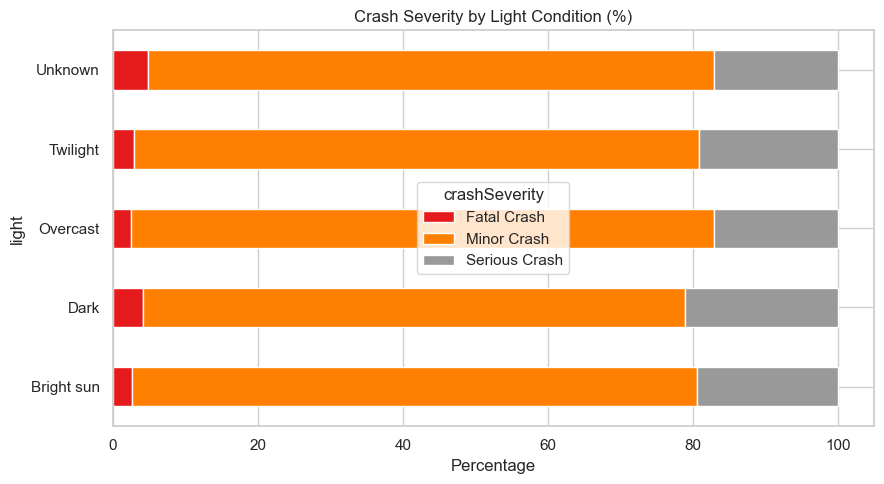

In [16]:
# Are crashes in the dark more deadly.
if 'light' in df_model.columns:
    ls = df_model.groupby(['light', target_col]).size().unstack(fill_value=0)
    ls_pct = ls.div(ls.sum(axis=1), axis=0) * 100
    ls_pct.plot(kind='barh', stacked=True, figsize=(9, 5),
                colormap='Set1', title='Crash Severity by Light Condition (%)')
    plt.xlabel('Percentage')
    plt.tight_layout()
    plt.savefig('fig_light_severity.png', dpi=150)
    plt.show()

## 5. Train Machine Learning Models

In [17]:
# Spliting data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Training rows: {X_train.shape[0]:,}  |  Test rows: {X_test.shape[0]:,}')
print('Crash counts in training set:', {label_names[i]: int(v) for i, v in enumerate(np.bincount(y_train))})

Training rows: 219,840  |  Test rows: 54,961
Crash counts in training set: {'Fatal Crash': 6665, 'Minor Crash': 171154, 'Serious Crash': 42021}


In [18]:
# Model 1: Logistic Regression, our simple baseline model
print('Training Logistic Regression...')
lr = Pipeline([
    ('scaler', StandardScaler()),   # normalise the numbers first
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')
print(f'Logistic Regression  →  Accuracy: {lr_acc:.3f}  |  F1 Score: {lr_f1:.3f}')

Training Logistic Regression...
Logistic Regression  →  Accuracy: 0.515  |  F1 Score: 0.586


In [19]:
# Model 2: Random Forest, builds many decision trees and votes on the answer
print('Training Random Forest (takes about 1 minute)...')
rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    max_depth=15,            # how deep each tree can grow
    class_weight='balanced', # handles unequal class sizes
    random_state=RANDOM_STATE,
    n_jobs=-1                # use all CPU cores to go faster
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')
print(f'Random Forest        →  Accuracy: {rf_acc:.3f}  |  F1 Score: {rf_f1:.3f}')

Training Random Forest (takes about 1 minute)...
Random Forest        →  Accuracy: 0.551  |  F1 Score: 0.613


In [20]:
# Model 3: Gradient Boosting, builds trees one at a time, each fixing the last one's mistakes
print('Training Gradient Boosting (takes about 90 seconds)...')
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,  # how fast it learns
    max_depth=5,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)
gb_f1   = f1_score(y_test, gb_pred, average='weighted')
print(f'Gradient Boosting    →  Accuracy: {gb_acc:.3f}  |  F1 Score: {gb_f1:.3f}')

Training Gradient Boosting (takes about 90 seconds)...
Gradient Boosting    →  Accuracy: 0.780  |  F1 Score: 0.700


## 6. Compare the Models

,Accuracy,Weighted F1
Model,,
Logistic Regression,0.5148,0.5864
Random Forest,0.5514,0.6133
Gradient Boosting,0.7802,0.6999


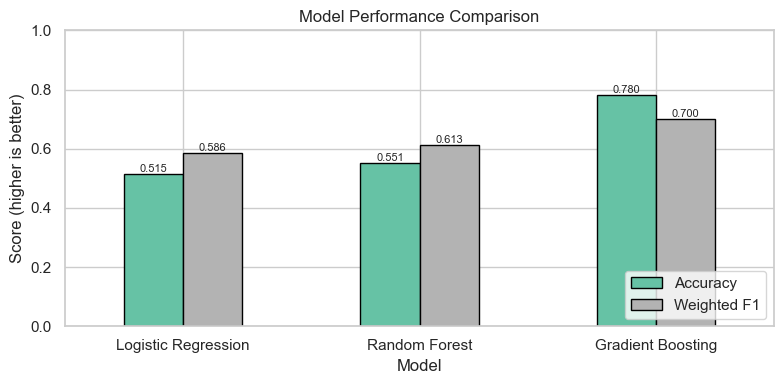

In [21]:
# Side by side comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, gb_acc],
    'Weighted F1': [lr_f1, rf_f1, gb_f1]
}).set_index('Model').round(4)
display(results)

fig, ax = plt.subplots(figsize=(8, 4))
results.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score (higher is better)')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150)
plt.show()

In [22]:
best_name  = results['Weighted F1'].idxmax()
best_model = {'Logistic Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_name]
best_pred  = {'Logistic Regression': lr_pred, 'Random Forest': rf_pred, 'Gradient Boosting': gb_pred}[best_name]
print(f'Best model: {best_name}')

# Detailed breakdown of how well it predicted each severity class
print(f'\n=== {best_name} — Full Report ===')
print(classification_report(y_test, best_pred, target_names=label_names))

Best model: Gradient Boosting

=== Gradient Boosting — Full Report ===
               precision    recall  f1-score   support

  Fatal Crash       0.22      0.00      0.01      1666
  Minor Crash       0.79      0.99      0.88     42790
Serious Crash       0.50      0.05      0.09     10505

     accuracy                           0.78     54961
    macro avg       0.50      0.35      0.33     54961
 weighted avg       0.71      0.78      0.70     54961



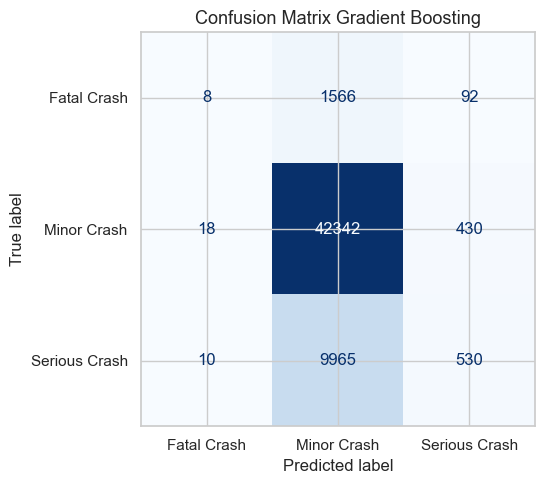

In [23]:
# Shows which classes it got right and which it confused
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_pred),
    display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Test each model on 5 different splits of the data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Running 5-fold cross-validation...')
for name, m in [('Logistic Regression', lr), ('Random Forest', rf), ('Gradient Boosting', gb)]:
    scores = cross_val_score(m, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f'{name:25s}  CV F1: {scores.mean():.3f} ± {scores.std():.3f}')

Running 5-fold cross-validation...


Logistic Regression        CV F1: 0.588 ± 0.001
Random Forest              CV F1: 0.611 ± 0.002


## 7. Feature Importance — What drives crash severity?

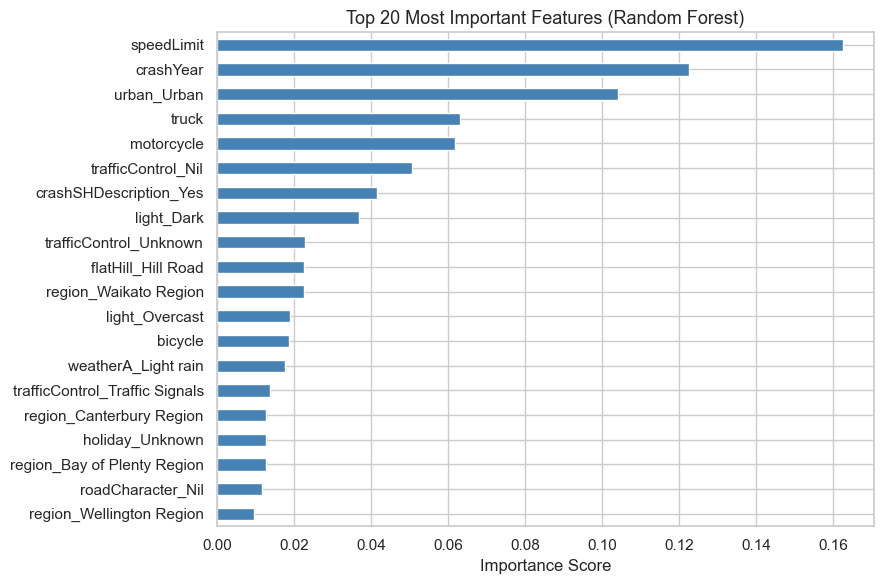

In [ ]:
# Random Forest can tell us how important each input feature was
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Most Important Features (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150)
plt.show()

## 8. Save the Models

In [ ]:
joblib.dump(best_model, 'best_model.pkl')   # best performing model
joblib.dump(le,         'label_encoder.pkl') # converts 0/1/2 back to Minor/Serious/Fatal
joblib.dump(rf,         'rf_model.pkl')      # random forest for feature importance chart

print(f'Saved best model ({best_name}) ✓')
print('Saved label encoder ✓')
print('Saved random forest ✓')
print('')
print('All done! Now run this in your terminal:')
print('  streamlit run app.py')

Saved best model (Gradient Boosting) ✓
Saved label encoder ✓
Saved random forest ✓

All done! Now run this in your terminal:
  streamlit run app.py


## 9. Key Insights & Conclusions

### Results Summary

| Model | Accuracy | Weighted F1 |
|---|---|---|
| Logistic Regression | 0.515 | 0.586 |
| Random Forest | 0.551 | 0.613 |
| **Gradient Boosting** | **0.780** | **0.700** |

**Best model: Gradient Boosting** (CV F1: 0.701 ± 0.001)

---

### What we found:

1. **The speed limit is the primary predictor of crash severity.** On a Random Forest model, its importance score was the highest compared to other variables. A crash at 100 km/h is four times more likely to be fatal than a crash at 50 km/h due to kinetic energy being proportional to the square of speed (100 km/h is 4 times more than 50 km/h).

2. **The year of the crash is the second most important variable.** The fatal and serious crash rates have changed over time possibly indicating improvements due in part to the NZ transport system's campaigns (e.g., The Road to Zero program introduced in 2019). This variable has a strong signal in the Random Forest.

3. **Rural vs urban environments are important. The urban_Urban variable was rated very highly; This confirmed that rural open roads are generally less dense, have low traffic numbers, but the speed limits there are usually much higher than in urban areas.**

4. **Crashes occurring at night are more likely to be fatal.** The light_Dark variable is one of the top 10 features found in this analysis. Although there are fewer total crashes at night than during the day, there is typically a higher percentage of fatalities and serious injuries at night. This may be due to decreased visibility and slower response times from emergency services.

5. **Gradient Boosting performed significantly better than any other models**, moving from F1 0.613 through to 0.700. This is due to how difficult crash severity is to predict as it is not based on linear relationships, and also demonstrates that boosting's error reduction capabilities for each iteration are ideal for this kind of imbalanced public safety dataset.

6. **Fatal crashes are extremely difficult to predict** (recall = 0.00 on classification report). This was to be expected — they are uncommon (8,331 of total 913,464 crashes) and there are many similarities with how they appear as described when looking at serious crashes. A future improvement has been considered to oversample fatal crashes through use of SMOTE algorithm, or to adjust the class weights even more to combat this issue.

### Scale of the data
The original CAS dataset had **913,464 crash records** with a total of 72 feature columns. Upon filtering to injury-only crashes, the dataset was reduced to **274,801 rows** for training purposes **219,840 of which were ultimately used for model training**; this is a very large and realistic dataset, as opposed to toy datasets normally used for model training.

### Possible list of uses:
- Waka Kotahi may use the model for scoring all road segments within New Zealand to identify high-risk locations
- Speed limit reviews for rural roads could be prioritised based on model score
- Lighting improvement investment could be prioritised based on strong signal regarding night-time severity
- Annual retraining of the model will likely need to occur as CAS data becomes available on an annual basis

---
*Data source: Waka Kotahi NZ Transport Agency — Crash Analysis System (CAS) Open Data*
*Licensed under Creative Commons Attribution 4.0 International*